# Exploratory Analysis of Architectural Ratings

This notebook documents the analysis pipeline for the five rating items (*Hominess, Naturalness, Personalness, Beauty, Approachability*), including data preparation, exploratory checks, dimensionality reduction (PCA), and group comparisons by **Category**. This analysis is for **ASD** populations.

# Data Preparation

## Loading libraries

In [2]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and inspect dataset

In [9]:
## Load and inspect dataset
# load the data
file_path = "Data_exp2.xlsx"  # Update with the correct path if needed
df = pd.read_excel(file_path)
# quick check
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ImageNumber      880 non-null    int64 
 1   PredHominess     880 non-null    object
 2   Hominess         880 non-null    int64 
 3   Naturalness      880 non-null    int64 
 4   Personalness     880 non-null    int64 
 5   Beauty           880 non-null    int64 
 6   Approachability  880 non-null    int64 
 7   Participant      880 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 55.1+ KB
None


In [7]:
# check the size of the data frame
size_dim = df.shape
print(f"The size of this data frame: {size_dim}")
# check if there are missing values
missing_rows = df.isnull().any(axis=1).sum()
print(f"Number of rows with missing values: {missing_rows}")

The size of this data frame: (880, 8)
Number of rows with missing values: 0


In [8]:
df['Participant'].value_counts()

Participant
1     80
2     80
3     80
4     80
5     80
6     80
7     80
8     80
9     80
10    80
11    80
Name: count, dtype: int64

Right now, we have 11 participants, each of them completed 80 trials.

In [6]:
df['PredHominess'].unique()

array(['Plus', 'Minus'], dtype=object)

Unlike the data of neurotypical population, the ASD data only have two dimensions for catgeory: plus and minus.

In [11]:
mapping = {
    'Plus': 'Combined+',
    'Minus': 'Combined-'
}
df['Category'] = df['PredHominess'].map(mapping)
df['Category'].value_counts()

Category
Combined+    440
Combined-    440
Name: count, dtype: int64

# Exploratory analysis

## Distributions of rating variables

We can first check the statistics of the rating columns, then plot their distributions.

In [13]:
rating_cols = ['Hominess', 'Naturalness', 'Personalness', 'Beauty', 'Approachability']
rating_df = df[rating_cols]
# Summary statistics
print(rating_df.describe())

         Hominess  Naturalness  Personalness      Beauty  Approachability
count  880.000000   880.000000    880.000000  880.000000       880.000000
mean     3.911364     3.860227      3.811364    4.214773         4.676136
std      1.989474     2.068730      1.941314    1.970317         2.008712
min      1.000000     1.000000      1.000000    1.000000         1.000000
25%      2.000000     2.000000      2.000000    3.000000         3.000000
50%      4.000000     4.000000      4.000000    5.000000         5.000000
75%      5.250000     6.000000      5.000000    6.000000         6.000000
max      7.000000     7.000000      7.000000    7.000000         7.000000


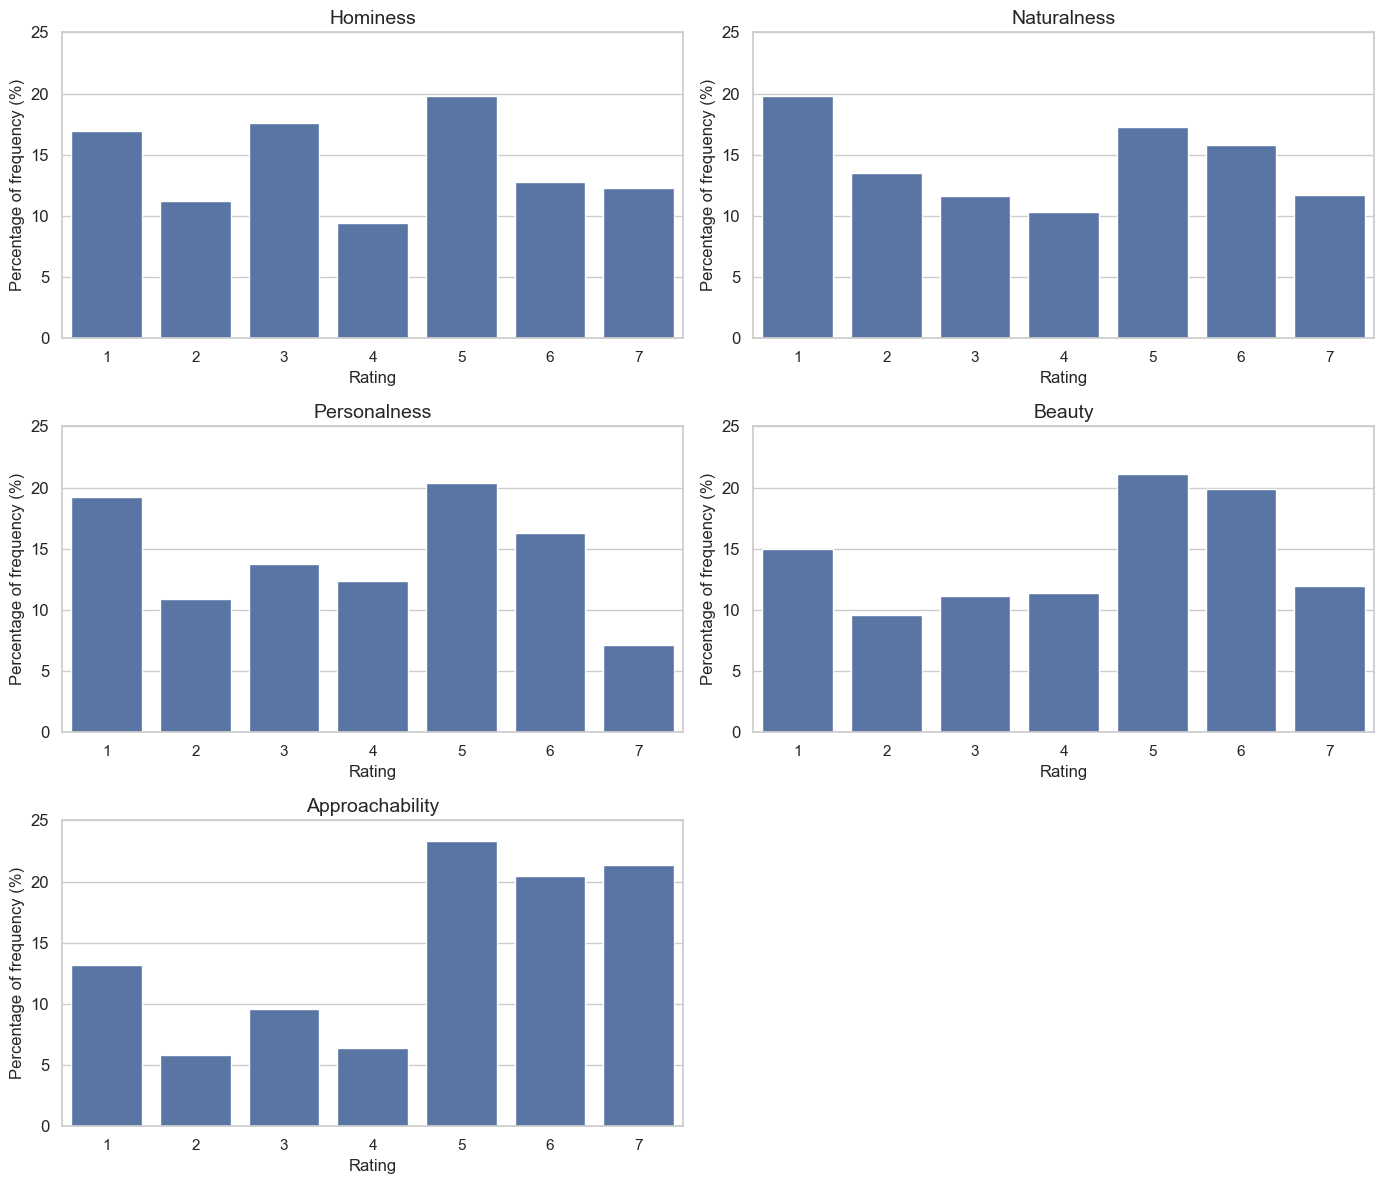

In [15]:
# Set clean academic style
sns.set(style="whitegrid")

plt.figure(figsize=(14, 12))

for i, col in enumerate(rating_cols, 1):
    plt.subplot(3, 2, i)

    # Count frequencies and convert to percentage
    counts = df[col].value_counts().sort_index()

    # Ensure all rating levels appear (1–7)
    counts = counts.reindex([1, 2, 3, 4, 5, 6, 7], fill_value=0)

    percent = counts / counts.sum() * 100

    # Vertical bar plot WITHOUT hue (to avoid FutureWarning)
    sns.barplot(
        x=percent.index,          # Rating levels (1–7)
        y=percent.values         # Percentage values
    )

    # Titles and labels
    plt.title(col, fontsize=14)
    plt.ylabel("Percentage of frequency (%)", fontsize=12)
    plt.xlabel("Rating", fontsize=12)
    plt.ylim(0,25)
    plt.yticks(np.arange(0, 30, step=5), fontsize=12)


plt.tight_layout()
plt.show()

## Inter-variable correlations

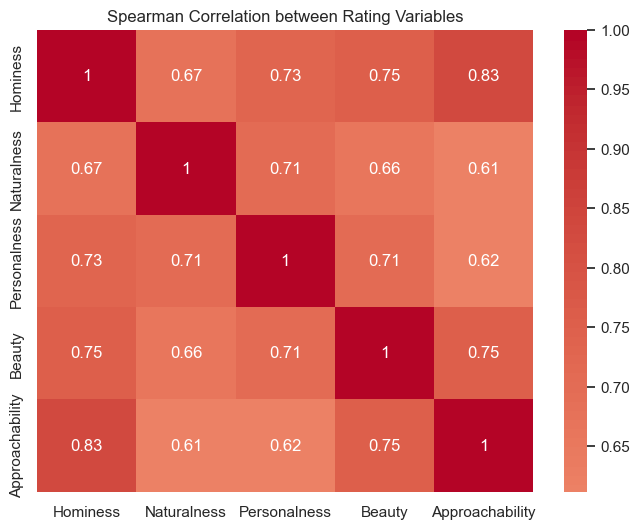

In [16]:
# Spearman correlation
corr = rating_df.corr(method="spearman")
# heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation between Rating Variables")
plt.show()

## Consistency analysis (Cronbach's alpha)

In [17]:
import pingouin as pg
alpha = pg.cronbach_alpha(data=rating_df)
print("Cronbach’s alpha:", alpha)

Cronbach’s alpha: (0.9224954931051083, array([0.914, 0.93 ]))


# Dimensionality Reduction

In [18]:
# load libraries for PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## PCA

In [19]:
# Standardize variables and run PCA
X_scaled = StandardScaler().fit_transform(rating_df)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
print("Explained variance ratio:", explained_var)
print("Cumulative explained variance:", cumulative_var)

Explained variance ratio: [0.76486892 0.09404096 0.06031602 0.05177468 0.02899943]
Cumulative explained variance: [0.76486892 0.85890988 0.91922589 0.97100057 1.        ]


## Scree Plot

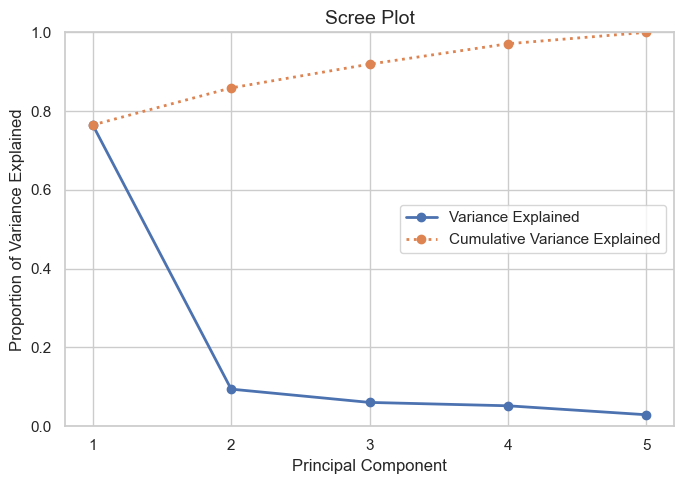

In [22]:
# Create a single plot instead of subplots
plt.figure(figsize=(7, 5))

# Plot explained variance (proportion)
plt.plot(
    range(1, len(explained_var) + 1),
    explained_var,
    marker='o',
    label="Variance Explained",
    linewidth=2
)

# Plot cumulative variance
plt.plot(
    range(1, len(cumulative_var) + 1),
    cumulative_var,
    marker='o',
    linestyle='dotted',
    label="Cumulative Variance Explained",
    linewidth=2
)

# Axis labels and title
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Proportion of Variance Explained", fontsize=12)
plt.title("Scree Plot", fontsize=14)
plt.ylim(0, 1)

# Set x ticks
plt.xticks(np.arange(1, len(explained_var) + 1, 1))

# Add legend
plt.legend()

plt.tight_layout()
plt.show()



In [23]:
df['mean_rating'] = df[rating_cols].mean(axis=1)

# Parametric tests
## ANOVA or t test?

In [25]:
df_subject = df.groupby(["Participant", "Category"])["mean_rating"].mean().reset_index()
df_subject.groupby(["Category"])["mean_rating"].agg(['mean', 'std'])

,mean,std
Category,,
Combined+,5.023182,0.497329
Combined-,3.166364,0.940394
